# Causal Inference on Yelp Reviews

## What makes a review considered Useful?

Imagine you're looking for a new restaurant for the weekend. You open Yelp and see dozens of reviews — but you only read a few carefully. Which ones? Almost certainly the ones with the most **"Useful"** votes.

That raises a very practical question: **what makes a review truly helpful?**

The three most common hypotheses:

- Reviews with **higher star ratings** -> more positive, more pleasant, and more likely to be liked
- **Longer reviews** -> more detailed, information-rich, and genuinely helpful
- Reviews from **Elite users** -> credibility badge, higher community trust

But here's the issue: *what sounds reasonable isn’t necessarily causally true.*

Elite users tend to write better, write more often, and have more followers. When we observe that their reviews receive more votes, we can’t tell whether the cause is the **Elite badge** or their **intrinsic writing ability**. This is a classic **confounding** problem — and simple average comparisons cannot resolve it.

---

## Research Question

Instead of asking "which factors are *correlated* with useful votes," we ask a more precise question:

> **Which factors truly have a causal effect on the number of useful votes — after controlling for all confounding variables?**

---

## Causal Framework

| Symbol | Role | Variables |
|--------|------|-----------|
| **T** | Treatment | `stars`, `log_text_len`, `is_elite` |
| **Y** | Outcome | `log1p(useful_votes)` |
| **X** | Confounders | user quality, review age (nonlinear), sentiment, business type |

---

## Method: Double Machine Learning

To separate causality from correlation, we use **Double Machine Learning (DML)**, implemented via Microsoft Research's EconML library.

Core idea: instead of directly regressing Y on T (which is prone to confounding), DML "cleans" both before comparison:

1. Use an ML model to predict **T from X** -> take residuals *(the part of treatment not explained by confounders)*
2. Use an ML model to predict **Y from X** -> take residuals *(the part of outcome not explained by confounders)*
3. Regress residual Y on residual T -> coefficient = **Average Treatment Effect (ATE)**

Gradient Boosting is used for the outcome model (flexible, nonlinear). 5-fold cross-fitting helps prevent overfitting during nuisance estimation.

## 0. Setup

Install the required libraries and set up the environment. `EconML` is a causal inference library from Microsoft Research that provides `LinearDML`. `vaderSentiment` is used to compute sentiment scores from text. `lightgbm` serves as the backend for Gradient Boosting.

In [1]:
!pip install -q kagglehub[pandas-datasets] vaderSentiment scikit-learn econml lightgbm networkx wordcloud


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 5.2 MB/s eta 0:00:00


In [2]:
import json, random, warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from sklearn.linear_model import RidgeCV, LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from econml.dml import LinearDML
from wordcloud import WordCloud, STOPWORDS
import kagglehub

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'serif', 'font.size': 10,
})
C_BLUE = '#1a3a5c'  # significant
C_GRAY = '#aaaaaa'  # not significant
C_RED  = '#c0392b'  # Elite


## 1. Causal DAG - The Causal Map

Before writing a single line of modeling code, we need to explicitly define our **causal assumptions**: what affects what?

A Causal DAG (Directed Acyclic Graph) does exactly that. Each arrow in the graph represents a direct causal relationship between variables. This is not just a decorative step - it determines which variables should be included in the model and which should not.

### Structural Assumptions

**Confounders (X):** Variables that influence both the treatment and the outcome - if not controlled for, they create spurious correlations.

- `user_quality` (review_count, useful_total, fans, friends): Experienced users are more likely to receive the Elite badge, write longer reviews, and get more votes. This is the most important confounder.
- `sentiment (VADER)`: Emotional tone affects both how people write (stars, length) and how readers react (votes).
- `review_age (log + bins)`: Older reviews have more time to accumulate votes - not necessarily because they are better.
- `business_type`: Restaurants vs nail salons have different audiences and voting behaviors.

**Note on mediator:** `vader_sentiment` is correlated with `is_elite` (Elite users tend to write in a more balanced tone). We treat it as a confounder rather than removing it - removing it would introduce omitted variable bias. As a result, the ATE of Elite reflects the **direct effect of the badge**, not the total effect mediated through writing style.

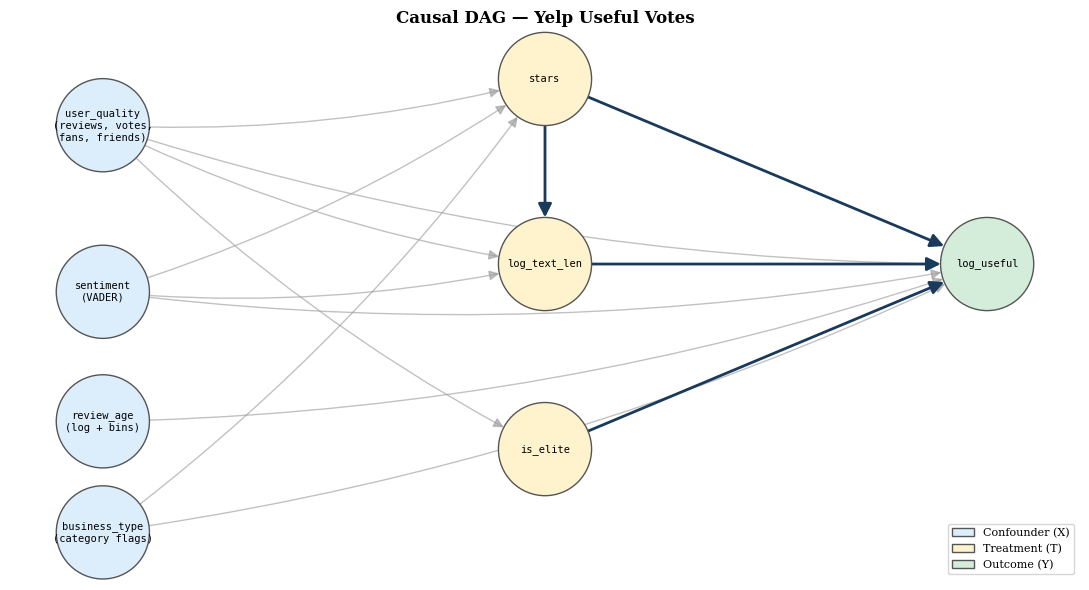

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_title('Causal DAG — Yelp Useful Votes', fontsize=12, fontweight='bold')

conf_edges = [
    ('user_quality\n(reviews, votes,\nfans, friends)', 'stars'),
    ('user_quality\n(reviews, votes,\nfans, friends)', 'log_text_len'),
    ('user_quality\n(reviews, votes,\nfans, friends)', 'is_elite'),
    ('user_quality\n(reviews, votes,\nfans, friends)', 'log_useful'),
    ('sentiment\n(VADER)', 'stars'),
    ('sentiment\n(VADER)', 'log_text_len'),
    ('sentiment\n(VADER)', 'log_useful'),
    ('review_age\n(log + bins)', 'log_useful'),
    ('business_type\n(category flags)', 'stars'),
    ('business_type\n(category flags)', 'log_useful'),
]
treat_edges = [
    ('stars', 'log_useful'),
    ('log_text_len', 'log_useful'),
    ('is_elite', 'log_useful'),
    ('stars', 'log_text_len'),
]
G = nx.DiGraph()
for u, v in conf_edges + treat_edges:
    G.add_edge(u, v)

pos = {
    'user_quality\n(reviews, votes,\nfans, friends)': (0, 3),
    'sentiment\n(VADER)':          (0, 1.2),
    'review_age\n(log + bins)':    (0, -0.2),
    'business_type\n(category flags)': (0, -1.4),
    'stars':        (4, 3.5),
    'log_text_len': (4, 1.5),
    'is_elite':     (4, -0.5),
    'log_useful':   (8, 1.5),
}
nc = {
    'user_quality\n(reviews, votes,\nfans, friends)': '#dceefb',
    'sentiment\n(VADER)':          '#dceefb',
    'review_age\n(log + bins)':    '#dceefb',
    'business_type\n(category flags)': '#dceefb',
    'stars':        '#fff3cd',
    'log_text_len': '#fff3cd',
    'is_elite':     '#fff3cd',
    'log_useful':   '#d4edda',
}
nx.draw_networkx_edges(G, pos, edgelist=conf_edges, ax=ax,
    edge_color='#999', arrows=True, arrowsize=15,
    connectionstyle='arc3,rad=0.08', node_size=4500, alpha=0.6)
nx.draw_networkx_edges(G, pos, edgelist=treat_edges, ax=ax,
    edge_color=C_BLUE, arrows=True, arrowsize=20, width=2, node_size=4500)
nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=[nc[n] for n in G.nodes()],
    node_size=4500, edgecolors='#555', linewidths=1)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.5, font_family='monospace')
ax.legend(handles=[
    mpatches.Patch(fc='#dceefb', ec='#555', label='Confounder (X)'),
    mpatches.Patch(fc='#fff3cd', ec='#555', label='Treatment (T)'),
    mpatches.Patch(fc='#d4edda', ec='#555', label='Outcome (Y)'),
], loc='lower right', fontsize=8)
ax.axis('off')
plt.tight_layout()
plt.show()


## 2. Load & Clean Data

### Data Source

We use the [Yelp Open Dataset](https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset) - a public dataset containing millions of real-world reviews. Three files are used:

- `review.json` - each row is a review: text, stars, useful votes, posting date  
- `user.json` - each row is a user: review_count, fans, Elite status, friend list  
- `business.json` - each row is a business: name, location, categories  

These files are merged via `user_id` and `business_id` so that each observation contains complete information about the review + user + business.

### The Elite Over-Sampling Problem

When randomly sampling 200,000 reviews from `review.json`, Elite users appear at a frequency of ~24% in the sample - while their actual proportion in the Yelp population is only about 5%. Why? Because Elite users write far more reviews on average. An Elite user who writes 200 reviews appears 200 times in the pool, while a regular user who writes only 5 reviews appears just 5 times.

As a result, the DML model learns from a "world" where Elite users are overrepresented. The estimated ATE no longer reflects the real population.

**Fix:** After merging, we downsample Elite users to ~5% - matching Yelp’s true population ratio.

### Data Cleaning Steps

Beyond fixing the sampling issue, several standard cleaning steps are applied: removing very short reviews (< 50 characters), removing duplicate texts, and clipping extreme useful vote counts at the 99th percentile to prevent a few viral reviews from skewing the entire analysis.

In [4]:
path = kagglehub.dataset_download('yelp-dataset/yelp-dataset')

# Step 1: Sample reviews
def reservoir_sample(fp, k, fields):
    sample = []
    with open(fp, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            d = json.loads(line)
            row = {fld: d.get(fld) for fld in fields}
            if i < k:
                sample.append(row)
            else:
                j = random.randint(0, i)
                if j < k:
                    sample[j] = row
    return pd.DataFrame(sample)

df_raw = reservoir_sample(
    f'{path}/yelp_academic_dataset_review.json', 200_000,
    ['user_id', 'business_id', 'text', 'stars', 'useful', 'funny', 'cool', 'date'],
)

# Step 2: Scan full user file (exact match)
target_uids = set(df_raw['user_id'].dropna().unique())
user_rows = []
with open(f'{path}/yelp_academic_dataset_user.json', 'r', encoding='utf-8') as f:
    for line in f:
        d = json.loads(line)
        if d.get('user_id') not in target_uids:
            continue
        friends_str = d.get('friends', '') or ''
        user_rows.append({
            'user_id':            d['user_id'],
            'user_review_count':  d.get('review_count', 0),
            'user_useful_total':  d.get('useful', 0),
            'user_fans':          d.get('fans', 0),
            'user_friends_count': len(friends_str.split(',')) if friends_str.strip() else 0,
            'is_elite':           int(bool(d.get('elite', ''))),
        })
df_user = pd.DataFrame(user_rows)

# Step 3: Scan business file
target_bids = set(df_raw['business_id'].dropna().unique())
biz_rows = []
with open(f'{path}/yelp_academic_dataset_business.json', 'r', encoding='utf-8') as f:
    for line in f:
        d = json.loads(line)
        if d.get('business_id') not in target_bids:
            continue
        cats = (d.get('categories') or '').lower()
        biz_rows.append({
            'business_id':   d['business_id'],
            'is_restaurant': int('restaurant' in cats),
            'is_bar':        int('bar' in cats or 'pub' in cats),
            'is_fastfood':   int('fast food' in cats or 'fastfood' in cats),
        })
df_biz = pd.DataFrame(biz_rows)

#  Step 4: Clean and merge
df = df_raw.dropna(subset=['text', 'stars', 'useful']).copy()
df['text'] = df['text'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
df = df[df['text'].str.len() >= 50].drop_duplicates(subset=['text'])
df = df[df['useful'] <= df['useful'].quantile(0.99)]

df = df.merge(df_user, on='user_id',     how='inner')
df = df.merge(df_biz,  on='business_id', how='left')
for col in ['is_restaurant', 'is_bar', 'is_fastfood']:
    df[col] = df[col].fillna(0).astype(int)

print(f'After merge    : {len(df):,} reviews')
print(f'Elite share    : {df["is_elite"].mean():.2%}  (before reweighting)')

# Step 5: Fix Elite over-sampling
TARGET_ELITE_RATE = 0.05
n_elite   = (df['is_elite'] == 1).sum()
n_regular = (df['is_elite'] == 0).sum()
n_elite_keep = min(int(n_regular * TARGET_ELITE_RATE / (1 - TARGET_ELITE_RATE)), n_elite)

df = pd.concat([
    df[df['is_elite'] == 1].sample(n_elite_keep, random_state=SEED),
    df[df['is_elite'] == 0],
], ignore_index=True).sample(min(150_000, len(df)), random_state=SEED).reset_index(drop=True)

print(f'After reweight : {len(df):,} reviews')
print(f'Elite share    : {df["is_elite"].mean():.2%}  (target ~{TARGET_ELITE_RATE:.0%})')
print(f'Elite N        : {df["is_elite"].sum():,}')


Using Colab cache for faster access to the 'yelp-dataset' dataset.
After merge    : 197,784 reviews
Elite share    : 24.33%  (before reweighting)
After reweight : 150,000 reviews
Elite share    : 4.99%  (target ~5%)
Elite N        : 7,481


## 3. Feature Engineering

Raw data is not sufficient for a causal model - it must be transformed into features that properly reflect the assumed causal structure.

### Sentiment from Text (VADER)

Review text is a "black box" containing many confounding signals. Someone writing in an angry or sarcastic tone may give low stars and write longer reviews - but that same tone also affects whether readers vote the review as useful. Without controlling for sentiment, we might mistakenly attribute the effect of tone to stars or length.

VADER (Valence Aware Dictionary and sEntiment Reasoner) converts text into three measurable scores: `compound` (aggregate score from -1 to +1), `pos`, and `neg`. These three values are included as confounders.

### Review Age - Nonlinearity is Key

Review age affects votes in a **nonlinear** way: very new reviews haven't been seen much, reviews that are 11-3 years old sit in a "golden window" for accumulating votes, and very old reviews tend to get buried in the feed. Therefore, we encode it in two ways:

- `log_review_age`: captures the overall trend  
- `age_bin` dummies (<1yr, 11-3yr, 31-5yr, >5yr): capture nonlinear stage effects  

This has a significant impact on the ATE of stars - because early-era 1-star reviews accumulate votes mechanically over time, not necessarily due to quality.

### Outcome: Log Scale

`log_useful = log1p(useful_votes)` is used instead of raw votes because the distribution is highly right-skewed (most reviews have 01-1 votes, while a few have dozens). The log scale stabilizes the model and allows ATE to be interpreted in percentage terms.

In [5]:
# Text
df['log_text_len'] = np.log(df['text'].str.len())
df['word_count']   = df['text'].str.split().str.len()

# Outcome
df['funny']      = pd.to_numeric(df['funny'], errors='coerce')
df['log_useful'] = np.log1p(df['useful'].clip(lower=0))
df['log_funny']  = np.log1p(df['funny'].fillna(0).clip(lower=0))

# Review age — log + coarse bins (captures nonlinear hump)
REF_DATE = pd.Timestamp('2022-01-01')
df['review_date']    = pd.to_datetime(df['date'], errors='coerce')
df['review_age_days'] = (REF_DATE - df['review_date']).dt.days.clip(lower=1)
df['log_review_age'] = np.log(df['review_age_days'])

age_cuts = [0, 365, 3*365, 5*365, np.inf]
age_labs  = ['<1yr', '1-3yr', '3-5yr', '>5yr']
df['age_bin'] = pd.cut(df['review_age_days'], bins=age_cuts, labels=age_labs)
age_dummies   = pd.get_dummies(df['age_bin'], prefix='age', drop_first=True)
df = pd.concat([df, age_dummies], axis=1)
AGE_DUMMIES = list(age_dummies.columns)

print('Feature engineering done.')
print(f'Age bin distribution:\n{df["age_bin"].value_counts().sort_index()}')
print(f'\nBusiness flags: restaurant={df["is_restaurant"].mean():.1%}  '
      f'bar={df["is_bar"].mean():.1%}  fastfood={df["is_fastfood"].mean():.1%}')


Feature engineering done.
Age bin distribution:
age_bin
<1yr     14426
1-3yr    32686
3-5yr    37657
>5yr     65231
Name: count, dtype: int64

Business flags: restaurant=67.1%  bar=27.9%  fastfood=3.4%


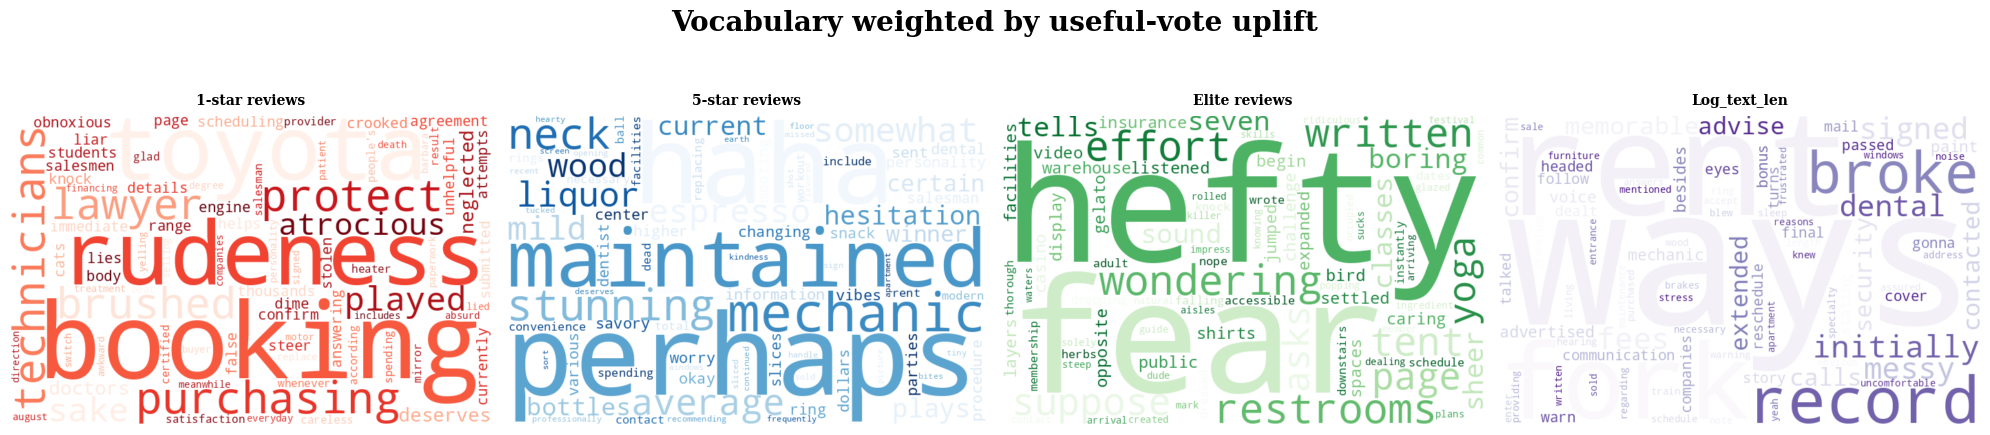

In [6]:
stops = STOPWORDS

def useful_weighted_freqs(texts_series, votes_series, n_sample=4000):
    """
    For each word: compute (mean useful votes of reviews containing that word)
    relative to overall mean. Returns {word: uplift_score}.
    Minimum 10 occurrences to filter noise.
    """
    idx = texts_series.sample(min(n_sample, len(texts_series)), random_state=SEED).index
    texts  = texts_series.loc[idx]
    votes  = votes_series.loc[idx]
    overall = votes.mean()

    word_votes = {}   # word -> list of vote counts
    for txt, v in zip(texts.values, votes.values):
        words = set(re.findall(r"[a-z']+", txt.lower()))
        for w in words:
            if w not in stops and len(w) > 3:
                word_votes.setdefault(w, []).append(v)

    freq = {}
    for w, vlist in word_votes.items():
        if len(vlist) < 10:
            continue
        uplift = (np.mean(vlist) - overall) / (overall + 0.1)
        if uplift > 0:
            freq[w] = uplift
    return freq


def make_weighted_wc(texts_s, votes_s, title, ax, colormap, n_sample=4000):
    freq = useful_weighted_freqs(texts_s, votes_s, n_sample)
    if not freq:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.axis('off'); return freq
    wc = WordCloud(
        width=700, height=450,
        background_color='white',
        colormap=colormap,
        max_words=80,
        min_font_size=9,
        prefer_horizontal=0.80,
        random_state=SEED,
    ).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    ax.axis('off')
    return freq

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    'Vocabulary weighted by useful-vote uplift',
    fontsize=20, fontweight='bold'
)

freq_1  = make_weighted_wc(df[df['stars']==1]['text'], df[df['stars']==1]['useful'],
                            '1-star reviews', axes[0], 'Reds')
freq_5  = make_weighted_wc(df[df['stars']==5]['text'], df[df['stars']==5]['useful'],
                            '5-star reviews', axes[1], 'Blues')
freq_el = make_weighted_wc(df[df['is_elite']==1]['text'], df[df['is_elite']==1]['useful'],
                            'Elite reviews', axes[2], 'Greens')
freq_tlen = make_weighted_wc(df[df['log_text_len'] > 0]['text'], df[df['log_text_len'] > 0]['useful'],
                            'Log_text_len', axes[3], 'Purples')

plt.tight_layout()
plt.show()

In [7]:
# Sentiment
sa = SentimentIntensityAnalyzer()
scores = df['text'].apply(lambda t: sa.polarity_scores(t))
df['vader_compound'] = scores.apply(lambda s: s['compound'])
df['vader_pos']      = scores.apply(lambda s: s['pos'])
df['vader_neg']      = scores.apply(lambda s: s['neg'])


## 4. Descriptive Statistics — What the Data Shows Before Causal Analysis

Before running any causal model, we first examine the raw data. This is an important step because it reveals *why* causal inference is necessary — many clear patterns in raw data are driven by confounding, not true causality.

The four charts below highlight several key observations:

**Vote distribution is highly skewed.** Most reviews receive 0 votes. Only about ~39% of reviews receive at least one vote. This does not mean most reviews are useless — it suggests that Yelp’s voting mechanism has high friction, and "breakthrough" reviews typically stand out for specific reasons.

**1-star reviews receive the most votes** (raw average ~1.29 vs 0.62 for 5-star). This is the first counterintuitive pattern — and it will later be confirmed through causal analysis.

**Elite users receive significantly more votes** (raw gap +1.11 votes). However, this is exactly where caution is needed: is this due to the badge itself, or their inherent ability? Raw comparisons cannot answer this.

**Review age has a nonlinear effect** — reviews aged 1–3 years receive the most votes, confirming the need for nonlinear encoding rather than using raw values.

> All of these patterns are observed *without* controlling for confounders. They motivate the need for causal inference — they are not conclusions.

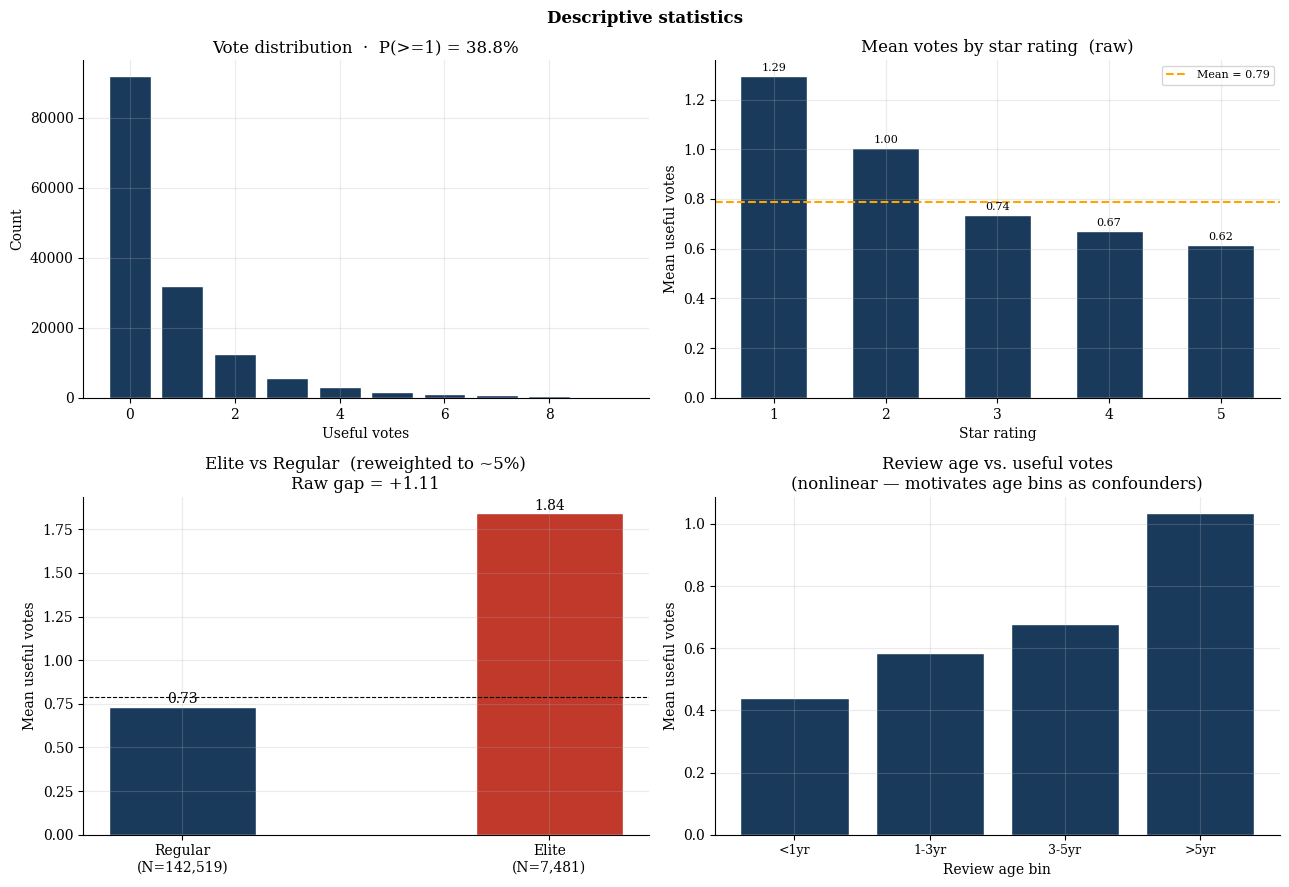

            stars      useful  log_text_len    is_elite  vader_compound  \
count  150000.000  150000.000    150000.000  150000.000      150000.000   
mean        3.699       0.790         5.907       0.050           0.596   
std         1.558       1.451         0.781       0.218           0.592   
min         1.000       0.000         3.912       0.000          -0.999   
25%         2.000       0.000         5.328       0.000           0.542   
50%         4.000       0.000         5.878       0.000           0.901   
75%         5.000       1.000         6.443       0.000           0.964   
max         5.000      11.000         8.517       1.000           1.000   

       user_review_count  log_review_age  
count         150000.000      150000.000  
mean              51.712           7.154  
std              167.796           1.058  
min                0.000           0.000  
25%                5.000           6.837  
50%               15.000           7.397  
75%               40.00

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Descriptive statistics', fontsize=12, fontweight='bold')

# (a) Vote distribution
v = df['useful'].values
axes[0,0].hist(v[v <= 10], bins=np.arange(0, 11) - 0.5,
               color=C_BLUE, edgecolor='white', rwidth=0.8)
axes[0,0].set_xlabel('Useful votes'); axes[0,0].set_ylabel('Count')
axes[0,0].set_title(f'Vote distribution  ·  P(>=1) = {(v>=1).mean():.1%}')

# (b) Mean useful by star rating
sm = df.groupby('stars')['useful'].mean()
axes[0,1].bar(sm.index, sm.values, color=C_BLUE, edgecolor='white', width=0.6)
for s, mv in zip(sm.index, sm.values):
    axes[0,1].text(s, mv + 0.02, f'{mv:.2f}', ha='center', fontsize=8)
axes[0,1].axhline(df['useful'].mean(), color='orange', lw=1.5, ls='--',
                  label=f'Mean = {df["useful"].mean():.2f}')
axes[0,1].set_xlabel('Star rating'); axes[0,1].set_ylabel('Mean useful votes')
axes[0,1].set_title('Mean votes by star rating  (raw)')
axes[0,1].legend(fontsize=8)

# (c) Elite vs Regular
labels = [f'Regular\n(N={int((df.is_elite==0).sum()):,})',
          f'Elite\n(N={int((df.is_elite==1).sum()):,})']
means  = [df[df.is_elite==0]['useful'].mean(), df[df.is_elite==1]['useful'].mean()]
axes[1,0].bar(labels, means, color=[C_BLUE, C_RED], edgecolor='white', width=0.4)
for i, mv in enumerate(means):
    axes[1,0].text(i, mv + 0.02, f'{mv:.2f}', ha='center', fontsize=10)
axes[1,0].axhline(df['useful'].mean(), color='black', lw=0.8, ls='--')
axes[1,0].set_ylabel('Mean useful votes')
axes[1,0].set_title(f'Elite vs Regular  (reweighted to ~5%)\nRaw gap = +{means[1]-means[0]:.2f}')

# (d) Review age bins vs useful votes
age_means = df.groupby('age_bin', observed=True)['useful'].mean()
axes[1,1].bar(range(len(age_means)), age_means.values, color=C_BLUE, edgecolor='white')
axes[1,1].set_xticks(range(len(age_means)))
axes[1,1].set_xticklabels(age_means.index, fontsize=9)
axes[1,1].set_xlabel('Review age bin')
axes[1,1].set_ylabel('Mean useful votes')
axes[1,1].set_title('Review age vs. useful votes\n(nonlinear — motivates age bins as confounders)')

plt.tight_layout()
plt.show()

print(df[['stars','useful','log_text_len','is_elite',
          'vader_compound','user_review_count','log_review_age']].describe().round(3))


## 5. Propensity Score Overlap - Pre-check Before Estimating Causal Effects for Elite

Before running DML on the `is_elite` variable (a binary treatment), we need to answer a critical question: **Do Elite and Regular users have sufficient overlap in the confounder space?**

If there is no overlap - meaning Elite users are completely different from Regular users across all dimensions - then any estimated ATE would be based on *extrapolation*, not *interpolation*. Extrapolation in causal inference is highly prone to bias.

**How to check:** Fit a logistic regression to estimate P(Elite | X) - known as the propensity score. If the two groups overlap well, their propensity score distributions should significantly overlap. If not, one group will cluster in high-probability regions and the other in low-probability regions, with minimal intersection.

**Result:** 53.4% of the sample lies within the common support region [0.02, 0.98]. About half of the sample has extreme propensity scores - meaning causal comparisons for those observations are less reliable.

**Application:** We use this result to construct a *trimmed sample* - keeping only observations within the common support region - and run DML on both the full and trimmed samples. If the results are consistent, it suggests that the ATE is not driven by extrapolation.

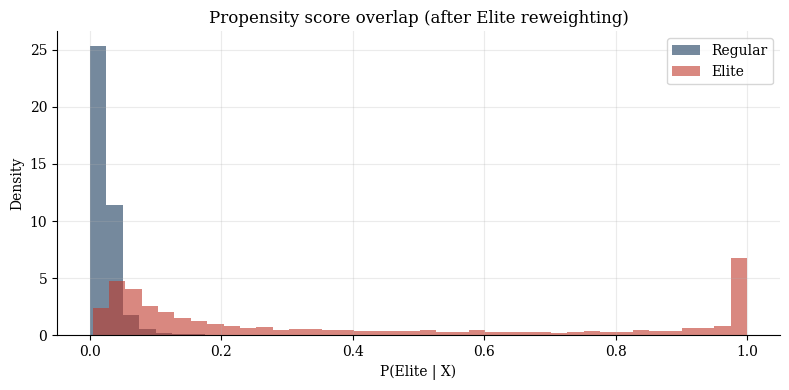

In common support [0.02, 0.98]: 80,172 / 150,000  (53.4%)
  Elite in support  : 6,046
  Regular in support: 74,126


In [9]:
CONFOUNDERS_ALL = (
    ['vader_compound', 'vader_pos', 'vader_neg', 'word_count',
     'user_review_count', 'user_useful_total', 'user_fans', 'user_friends_count',
     'log_review_age', 'is_restaurant', 'is_bar', 'is_fastfood']
    + AGE_DUMMIES
)

ov_data = df[CONFOUNDERS_ALL + ['is_elite']].dropna()
X_ov = StandardScaler().fit_transform(ov_data[CONFOUNDERS_ALL])
y_ov = ov_data['is_elite'].values

ps = (LogisticRegression(max_iter=500, random_state=SEED)
      .fit(X_ov, y_ov).predict_proba(X_ov)[:, 1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ps[y_ov==0], bins=40, alpha=0.6, color=C_BLUE, label='Regular', density=True)
ax.hist(ps[y_ov==1], bins=40, alpha=0.6, color=C_RED,  label='Elite',   density=True)
ax.set_xlabel('P(Elite | X)')
ax.set_ylabel('Density')
ax.set_title('Propensity score overlap (after Elite reweighting)')
ax.legend()
plt.tight_layout()
plt.show()

TRIM_LO, TRIM_HI = 0.02, 0.98
mask = (ps >= TRIM_LO) & (ps <= TRIM_HI)
print(f'In common support [{TRIM_LO}, {TRIM_HI}]: {mask.sum():,} / {len(mask):,}  ({mask.mean():.1%})')
print(f'  Elite in support  : {(y_ov[mask]==1).sum():,}')
print(f'  Regular in support: {(y_ov[mask]==0).sum():,}')

df['_in_support'] = False
df.loc[ov_data.index[mask], '_in_support'] = True


## 6. Causal Estimation — Double Machine Learning

DML addresses confounding by applying the **Frisch-Waugh-Lovell** idea, while replacing linear regression with more flexible machine learning models:

$$
Y_i = θ · T_i + g(X_i) + ε_i
$$

Here, $g(X)$ is an *unknown function* of confounders — its form does not need to be specified. A machine learning model (e.g., Gradient Boosting) learns this function directly from the data.

---

### Procedure

**Step 1 — Fit nuisance model for T**

Estimate:
$$
E[T \mid X]
$$

Compute residuals:
$$
T̃ = T - Ê[T \mid X]
$$

**Step 2 — Fit nuisance model for Y**

Estimate:
$$
E[Y \mid X]
$$

Compute residuals:
$$
Ỹ = Y - Ê[Y \mid X]
$$

**Step 3 — Final regression**

Run:
$$
Ỹ = θ̂ · T̃ + error
$$

The coefficient $θ̂$ is the **Average Treatment Effect (ATE)**.

---

### Why Cross-Fitting?

Cross-fitting (5 folds) ensures that residuals are computed on data not used to train the nuisance models, reducing overfitting and bias in the final estimate.

---

### Interpreting Results

Because the outcome is on a log scale, the ATE can be interpreted as:

$$
ATE (\% change) = (exp(θ̂) - 1) × 100\%
$$

This represents the percentage change in useful votes when the treatment increases by one unit, holding all confounders constant.

In [10]:
CONFOUNDERS = (
    ['vader_compound', 'vader_pos', 'vader_neg', 'word_count',
     'user_review_count', 'user_useful_total', 'user_fans', 'user_friends_count',
     'log_review_age', 'is_restaurant', 'is_bar', 'is_fastfood']
    + AGE_DUMMIES
)

def to_pct(log_ate):
    return (np.exp(log_ate) - 1) * 100

def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

def run_dml(df_in, treatment, outcome, confounders, binary=False, label=''):
    data = df_in[[treatment, outcome] + confounders].dropna()
    Y = data[outcome].values
    T = data[treatment].values
    W = data[confounders].values

    if binary:
        m_t = Pipeline([('sc', StandardScaler()),
                        ('lr', LogisticRegressionCV(Cs=10, cv=3,
                                                    max_iter=1000,
                                                    random_state=SEED))])
    else:
        m_t = Pipeline([('sc', StandardScaler()),
                        ('rc', RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]))])

    m_y = HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05, max_depth=4, random_state=SEED)

    dml = LinearDML(model_t=m_t, model_y=m_y,
                    discrete_treatment=binary, cv=5, random_state=SEED)
    dml.fit(Y, T, X=None, W=W)

    ate   = dml.ate(X=None)
    inf   = dml.ate_inference(X=None)
    ci_lo = inf.conf_int_mean()[0]
    ci_hi = inf.conf_int_mean()[1]
    p_val = inf.pvalue()

    print(f'  [{label}]  ATE = {ate:+.4f}  ({to_pct(ate):+.1f}%)  '
          f'95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}]  '
          f'p = {p_val:.4f} {sig_label(p_val)}  N={len(data):,}')

    return dict(label=label, ate=ate, se=inf.stderr_mean,
                ci_lo=ci_lo, ci_hi=ci_hi, p_val=p_val, N=len(data))

def evalue(log_ate, ci_bound):
    """E-value (VanderWeele & Ding 2017) for log-scale ATE."""
    rr    = np.exp(abs(log_ate))
    rr_ci = np.exp(abs(ci_bound))
    ev    = rr    + np.sqrt(rr    * (rr    - 1)) if rr    > 1 else 1.0
    ev_ci = rr_ci + np.sqrt(rr_ci * (rr_ci - 1)) if rr_ci > 1 else 1.0
    return ev, ev_ci


### Q1 — Do Star Ratings Actually Cause More Useful Votes?

**Initial intuition:** 5-star reviews are positive, pleasant to read, and more likely to be liked — so they should receive more votes.

**But looking at descriptive stats:** 1-star reviews have the highest average votes. This could be due to confounding — dissatisfied users tend to write more, and experienced users often write more detailed negative reviews. DML controls for all of these factors.

Below are the results after controlling for user quality, sentiment, review age, business type, and Elite status:

In [11]:
print('Q1 - Stars -> log_useful')
res_q1 = run_dml(df, 'stars', 'log_useful',
                 CONFOUNDERS + ['is_elite'],
                 label='Stars')
print(f'  -> Per 1-star increase : {to_pct(res_q1["ate"]):+.1f}%')
print(f'  -> From 1 to 5 stars  : {to_pct(res_q1["ate"] * 4):+.1f}%')


Q1 - Stars -> log_useful
  [Stars]  ATE = -0.0261  (-2.6%)  95% CI [-0.0285, -0.0237]  p = 0.0000 ***  N=150,000
  -> Per 1-star increase : -2.6%
  -> From 1 to 5 stars  : -9.9%


### Q1 Results: Stars → Useful Votes

**ATE = -2.6% per star (p < 0.001)**

After controlling for all confounders, each additional star **reduces** useful votes by ~2.6%. Moving from 1 star to 5 stars corresponds to roughly a ~10% decrease in votes.

**Why is it negative?** This result is counterintuitive but economically intuitive. Negative reviews often contain **specific, actionable information** — "the chicken was undercooked," "staff ignored the table for 20 minutes," "incorrect billing." Readers find these details useful because they help avoid risk. In contrast, 5-star reviews tend to be like "amazing, will come back!" — offering less concrete information for new customers.

This aligns with the *information value of negative reviews hypothesis* — and the data supports it after removing confounding effects.

**Note on magnitude:** The effect is statistically significant but modest in practical terms. Including review_age as a confounder improves estimation accuracy — since early-era 1-star reviews accumulate votes over time, failing to control for age would overestimate the effect of stars.

### Q2 — Do Longer Reviews Actually Provide More Value?

**Common hypothesis:** Longer reviews = more detail = more helpful. Many platforms even nudge users with prompts like "your review is a bit short, consider adding more detail."

**Problem with raw correlation:** Skilled users both write longer reviews and receive more votes. But the true driver may be *their ability*, not the length itself. DML controls for user quality to isolate whether length still has an effect when ability is held constant.

In [12]:
print('Q2 - Log text length -> log_useful')
res_q2 = run_dml(df, 'log_text_len', 'log_useful',
                 CONFOUNDERS + ['is_elite', 'stars'],
                 label='Length')
p25, p75 = np.percentile(df['text'].str.len(), [25, 75])
print(f'  -> P25->P75 ({int(p25)}->{int(p75)} chars): '
      f'{to_pct(res_q2["ate"] * (np.log(p75)-np.log(p25))):+.2f}%')
print(f'  -> Doubling length          : {to_pct(res_q2["ate"] * np.log(2)):+.2f}%')


Q2 - Log text length -> log_useful
  [Length]  ATE = +0.0057  (+0.6%)  95% CI [-0.0010, +0.0124]  p = 0.0947 n.s.  N=150,000
  -> P25->P75 (206->628 chars): +0.64%
  -> Doubling length          : +0.40%


### Q2 Results: Log Text Length → Useful Votes

**ATE = +0.6% per log unit (p = 0.09, n.s.)**

Review length shows **no statistically significant causal effect**. Even in an extreme scenario — doubling the review length — it only increases useful votes by ~0.4%, and this effect is not statistically significant.

**What does this mean?** The entire raw correlation between "longer reviews" and "more votes" is a **confounding illusion**. Experienced users both write longer reviews *and* receive more votes — but once we control for user quality, length itself has no causal predictive power.

**Practical implication:** If a platform encourages users to write longer reviews in hopes of increasing useful votes, that strategy is misguided. Investing in content quality (e.g., prompting users to include specific, actionable details) is far more effective than simply encouraging verbosity.

> **Note on R²:** The nuisance model \( Y \sim X \) has a low R², meaning useful votes are hard to predict from observable variables. This does not invalidate the DML results — it simply indicates that most of the variance comes from true content quality, which is not fully captured in the data.

### Q3 — Does the Elite Badge Actually Create Credibility?

This is the most difficult and interesting question of the three. Elite users outperform Regular users on nearly every dimension — ability, experience, and social network — so isolating the *pure* effect of the badge requires controlling for all of these factors.

To increase reliability, we estimate **three specifications** instead of just one:

1. **Full sample** (reweighted to ~5% Elite) — main estimate  
2. **Trimmed sample** (only observations within propensity score common support) — checks whether results are driven by extrapolation  
3. **Placebo test** (Elite → `log_funny`) — if the badge truly boosts *credibility*, it should affect *useful* votes only, not *funny* votes. If both increase, it may simply reflect a general popularity effect.

In [13]:
print('Q3 - Elite -> log_useful (full sample)')
res_q3 = run_dml(df, 'is_elite', 'log_useful',
                 CONFOUNDERS + ['stars'], binary=True, label='Elite (full)')

df_trim = df[df['_in_support']].copy()
print('Q3 - Elite -> log_useful (trimmed sample)')
res_q3t = run_dml(df_trim, 'is_elite', 'log_useful',
                  CONFOUNDERS + ['stars'], binary=True, label='Elite (trimmed)')

print('Placebo - Elite -> log_funny')
res_plac = run_dml(df, 'is_elite', 'log_funny',
                   CONFOUNDERS + ['stars'], binary=True, label='Elite -> funny (placebo)')

raw_gap = df[df.is_elite==1]['useful'].mean() - df[df.is_elite==0]['useful'].mean()
print(f'\n  Raw gap (Elite - Regular) : +{raw_gap:.3f} votes  (confounded)')
print(f'  Full sample ATE           : {to_pct(res_q3["ate"]):+.1f}%  {sig_label(res_q3["p_val"])}')
print(f'  Trimmed sample ATE        : {to_pct(res_q3t["ate"]):+.1f}%  {sig_label(res_q3t["p_val"])}')
print(f'  Placebo (funny)           : {to_pct(res_plac["ate"]):+.1f}%  {sig_label(res_plac["p_val"])}')


Q3 - Elite -> log_useful (full sample)
  [Elite (full)]  ATE = +0.0409  (+4.2%)  95% CI [+0.0251, +0.0568]  p = 0.0000 ***  N=150,000
Q3 - Elite -> log_useful (trimmed sample)
  [Elite (trimmed)]  ATE = +0.0387  (+3.9%)  95% CI [+0.0216, +0.0558]  p = 0.0000 ***  N=80,172
Placebo - Elite -> log_funny
  [Elite -> funny (placebo)]  ATE = -0.0007  (-0.1%)  95% CI [-0.0120, +0.0107]  p = 0.9103 n.s.  N=150,000

  Raw gap (Elite - Regular) : +1.108 votes  (confounded)
  Full sample ATE           : +4.2%  ***
  Trimmed sample ATE        : +3.9%  ***
  Placebo (funny)           : -0.1%  n.s.


### Q3 Results: Elite Badge → Useful Votes

**Full sample ATE = +4.2% (p < 0.001)**  
**Trimmed sample ATE = +3.9% (p < 0.001)**  
**Placebo (funny) ATE = -0.1% (p = 0.91, n.s.)**

Together, these three results tell a consistent story:

**Raw gap (+1.11 votes) vs. ATE (+4.2%):** Most of the raw difference between Elite and Regular users is driven by *ability* — skilled users earn the badge and also receive more votes because they are better. After controlling for this ability, the badge itself adds ~4% more votes — this is the "pure badge effect."

**Full ≈ Trimmed:** The estimates 4.2% and 3.9% are very close. If the result were driven by extrapolation in low-overlap regions, the trimmed sample would produce a very different estimate. This consistency increases credibility.

**Placebo is not significant:** The badge does not make reviews more *funny* — it only makes them more *useful* in the eyes of readers. This confirms the mechanism: the badge acts as a **credibility signal**, not a popularity signal. Readers see the Elite badge and place greater trust in the information presented in the review.

## 7. Stability Check — Does ATE Depend on Fold Splits?

DML relies on cross-fitting, meaning that random fold splits can potentially affect the results. If an ATE only appears under a specific random seed, that is a red flag.

To rule this out, we re-run all three models using 5 different random seeds (42, 123, 456, 789, 2024) and examine the variation in estimates.

A stable ATE should exhibit a small standard deviation and a narrow range across seeds — indicating that the result is not driven by a particular random split.

Running stability check (5 seeds)...


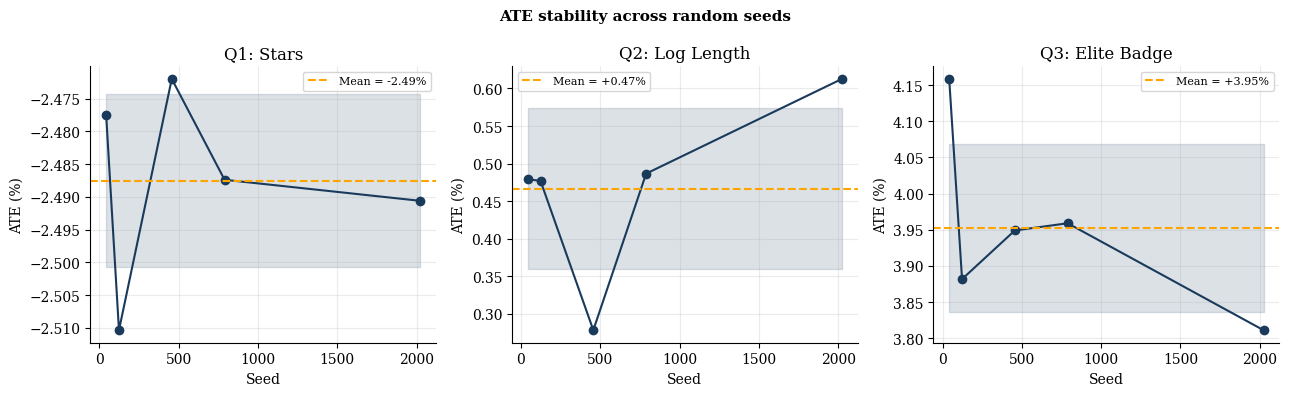


Stability summary:
  Q1 Stars    : mean=-2.49%  std=0.013%  range=[-2.51%, -2.47%]
  Q2 Length   : mean=+0.47%  std=0.107%  range=[+0.28%, +0.61%]
  Q3 Elite    : mean=+3.95%  std=0.116%  range=[+3.81%, +4.16%]


In [14]:
SEEDS = [42, 123, 456, 789, 2024]
stab = {'Q1_stars': [], 'Q2_length': [], 'Q3_elite': []}

print('Running stability check (5 seeds)...')
for s in SEEDS:
    def _fit(T_col, Y_col, extra, binary=False):
        cols = [T_col, Y_col] + CONFOUNDERS + extra
        d = df[cols].dropna()
        m_t = (Pipeline([('sc', StandardScaler()),
                         ('lr', LogisticRegressionCV(Cs=5, cv=3,
                                                     max_iter=500,
                                                     random_state=s))])
               if binary else
               Pipeline([('sc', StandardScaler()), ('rc', RidgeCV())]))
        mdl = LinearDML(
            model_t=m_t,
            model_y=HistGradientBoostingRegressor(max_iter=100, random_state=s),
            discrete_treatment=binary, cv=3, random_state=s)
        mdl.fit(d[Y_col].values, d[T_col].values,
                X=None, W=d[CONFOUNDERS + extra].values)
        return mdl.ate(X=None)

    stab['Q1_stars'].append(_fit('stars',        'log_useful', ['is_elite']))
    stab['Q2_length'].append(_fit('log_text_len', 'log_useful', ['is_elite', 'stars']))
    stab['Q3_elite'].append(_fit('is_elite',     'log_useful', ['stars'], binary=True))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('ATE stability across random seeds', fontsize=11, fontweight='bold')

for ax, (key, lbl) in zip(axes, [
        ('Q1_stars', 'Q1: Stars'),
        ('Q2_length','Q2: Log Length'),
        ('Q3_elite', 'Q3: Elite Badge')]):
    pcts = [to_pct(v) for v in stab[key]]
    mu, sd = np.mean(pcts), np.std(pcts)
    ax.plot(SEEDS, pcts, 'o-', color=C_BLUE)
    ax.axhline(mu, color='orange', ls='--', label=f'Mean = {mu:+.2f}%')
    ax.fill_between(SEEDS, mu - sd, mu + sd, alpha=0.15, color=C_BLUE)
    ax.set_title(lbl); ax.set_xlabel('Seed'); ax.set_ylabel('ATE (%)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nStability summary:')
for key, lbl in [('Q1_stars','Q1 Stars'),('Q2_length','Q2 Length'),('Q3_elite','Q3 Elite')]:
    pcts = [to_pct(v) for v in stab[key]]
    print(f'  {lbl:12}: mean={np.mean(pcts):+.2f}%  std={np.std(pcts):.3f}%  '
          f'range=[{min(pcts):+.2f}%, {max(pcts):+.2f}%]')


### Stability Check Results

- **Q1 Stars:** mean = -2.49%, std = 0.013% → **Extremely stable**  
- **Q2 Length:** mean = +0.47%, std = 0.107% → Stable (and still not statistically significant)  
- **Q3 Elite:** mean = +3.95%, std = 0.116% → **Stable**

None of the ATE estimates change meaningfully across the 5 seeds. This confirms that the results are not artifacts of a particular cross-fitting split.

## 8. Summary of results

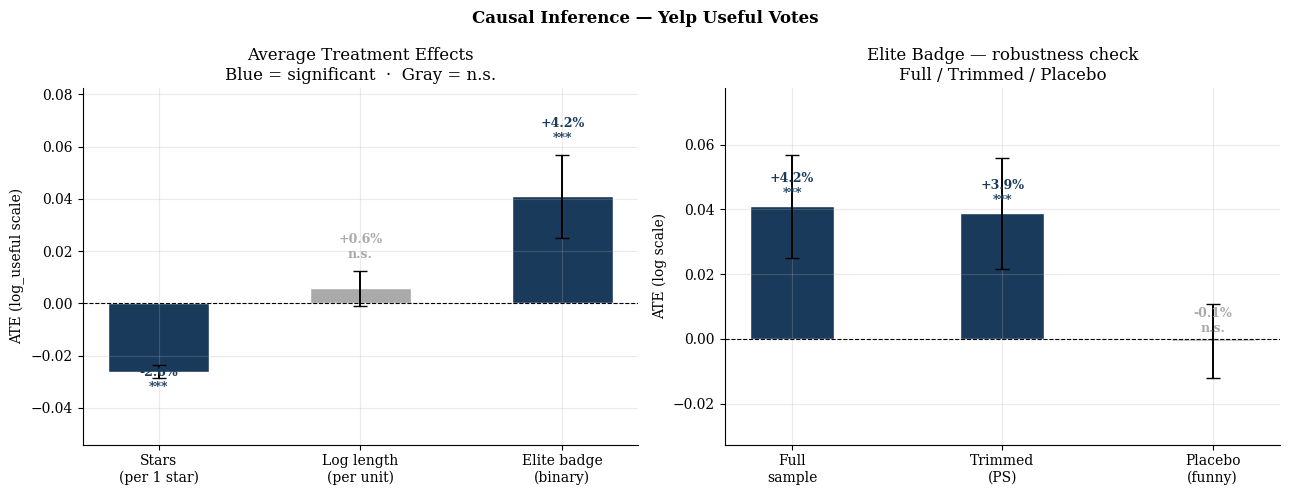

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Causal Inference — Yelp Useful Votes', fontsize=12, fontweight='bold')

# Panel A: main ATEs
main_res = [('Stars\n(per 1 star)', res_q1),
            ('Log length\n(per unit)', res_q2),
            ('Elite badge\n(binary)', res_q3)]
for i, (lbl, r) in enumerate(main_res):
    col = C_BLUE if r['p_val'] < 0.05 else C_GRAY
    axes[0].bar(i, r['ate'], color=col, edgecolor='white', width=0.5)
    axes[0].errorbar(i, r['ate'],
                     yerr=[[r['ate'] - r['ci_lo']], [r['ci_hi'] - r['ate']]],
                     fmt='none', color='black', capsize=5, lw=1.4)
    yoff = abs(r['ci_hi'] - r['ate']) + 0.005
    axes[0].text(i, r['ate'] + np.sign(r['ate']) * yoff,
                 f"{to_pct(r['ate']):+.1f}%\n{sig_label(r['p_val'])}",
                 ha='center', fontsize=9, fontweight='bold', color=col)
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_xticks(range(3))
axes[0].set_xticklabels([l for l, _ in main_res])
axes[0].set_ylabel('ATE (log_useful scale)')
axes[0].set_title('Average Treatment Effects\nBlue = significant  ·  Gray = n.s.')
axes[0].margins(y=0.3)

# Panel B: Elite robustness
specs = [('Full\nsample', res_q3),
         ('Trimmed\n(PS)', res_q3t),
         ('Placebo\n(funny)', res_plac)]
for i, (lbl, r) in enumerate(specs):
    col = C_BLUE if r['p_val'] < 0.05 else C_GRAY
    axes[1].bar(i, r['ate'], color=col, edgecolor='white', width=0.4)
    axes[1].errorbar(i, r['ate'],
                     yerr=[[r['ate'] - r['ci_lo']], [r['ci_hi'] - r['ate']]],
                     fmt='none', color='black', capsize=5, lw=1.4)
    axes[1].text(i, r['ate'] + 0.002,
                 f"{to_pct(r['ate']):+.1f}%\n{sig_label(r['p_val'])}",
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color=col)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_xticks(range(3))
axes[1].set_xticklabels([l for l, _ in specs])
axes[1].set_ylabel('ATE (log scale)')
axes[1].set_title('Elite Badge — robustness check\nFull / Trimmed / Placebo')
axes[1].margins(y=0.3)

plt.tight_layout()
plt.show()


## 9. Sensitivity Analysis — E-value

DML results control for *observed* confounders. However, unobserved confounders may still exist — such as image quality attached to reviews, niche expertise of the reviewer, or how Yelp’s algorithm ranks reviews.

The **E-value** measures how strong an unobserved confounder would need to be — in terms of risk ratio with both T and Y — to fully explain away the observed effect.

- Higher E-value → harder for unobserved confounding to invalidate the result → more robust  
- Low E-value (~1.1–1.3) → even weak confounding could explain away the effect  

This is an important step in *intellectual honesty*: not to dismiss the results, but to clearly communicate their level of robustness.

In [16]:
print(f"{'Treatment':<22} {'ATE%':>7} {'E-val(ATE)':>11} {'E-val(CI)':>10}  Sensitivity")
print('-' * 78)

cases = [
    ('Stars',           res_q1,  res_q1['ci_hi']),
    ('Log length',      res_q2,  res_q2['ci_lo']),
    ('Elite (full)',    res_q3,  res_q3['ci_lo']),
    ('Elite (trimmed)', res_q3t, res_q3t['ci_lo']),
]
for lbl, r, ci_b in cases:
    ev, ev_ci = evalue(r['ate'], ci_b)
    sens = 'Highly sensitive' if ev_ci < 1.5 else 'Moderately sensitive' if ev_ci < 2.0 else 'Robust'
    print(f'{lbl:<22} {to_pct(r["ate"]):>+7.1f}% {ev:>11.2f} {ev_ci:>10.2f}  {sens}')


Treatment                 ATE%  E-val(ATE)  E-val(CI)  Sensitivity
------------------------------------------------------------------------------
Stars                     -2.6%        1.19       1.18  Highly sensitive
Log length                +0.6%        1.08       1.03  Highly sensitive
Elite (full)              +4.2%        1.25       1.19  Highly sensitive
Elite (trimmed)           +3.9%        1.24       1.17  Highly sensitive


> **Important caveat:** An E-value of ~1.2 means that an unobserved confounder with a risk ratio of ~1.2 for both T and Y could fully explain away the result. Factors such as niche expertise, image quality attached to reviews, or Yelp’s internal ranking algorithm could plausibly reach this threshold. We have not observed all hidden confounders, nor identified one strong enough to make the causal conclusions fully robust — but we do have sufficient evidence to interpret the results carefully and to reject misleading conclusions drawn from raw data.

## 10. Conclusion

### Summary of Results

| Treatment | Direction | Statistical Significance | Stable? | Practical Magnitude |
|-----------|----------|--------------------------|----------|---------------------|
| Stars (per +1) | Negative (fewer votes) | Yes | Yes | Small (~2.6%) |
| Log text length | Positive | No (n.s.) | Yes | Negligible |
| Elite badge | Positive (more votes) | Yes | Yes | Small–Moderate (~4%) |

---

### Key Takeaways

We may not claim perfectly precise estimates, but through the **deconfounding process**, we have extracted meaningful signals from noisy data — showing that much of what appears in raw data is driven by confounding rather than true causality.

**Negative effect of stars** does not mean users dislike positive reviews — it reflects that negative reviews tend to contain more **specific, actionable information**. Readers seek risk-avoidance signals, not generic praise.

**No effect of length** is the clearest illustration of confounding: the entire raw correlation between length and votes is driven by *author ability*, not length itself.

**Elite badge works as intended** — it functions as a genuine **credibility filter**, not a vanity feature. The effect is specific to *useful* votes (not *funny*), and remains consistent across both full and trimmed samples.

---

### Limitations and Cautions

All E-values are relatively low (~1.1–1.3), meaning the results are **statistically valid but sensitive** to unobserved confounding. Factors such as Yelp’s internal ranking algorithm, image quality, or niche expertise — which are not measured — could be strong enough to alter conclusions. Therefore, these findings should be interpreted as **directional evidence**, not definitive causal claims.

---

### Future Directions

Three extensions could substantially improve the robustness of this study:

1. **Text embeddings or LLM-based content quality as additional confounders**  
   This is likely the most important missing confounder. If we can measure "true content quality" via embeddings or LLM scoring, E-values would likely increase significantly.

2. **CausalForestDML for heterogeneous treatment effects**  
   ATE captures only the population average. More interesting questions include: Does the Elite badge matter more for newcomers? For restaurants vs services? Heterogeneous effects can answer these.

3. **Instrumental variables for Elite status**  
   If a valid instrument can be found (affecting Elite status but not directly affecting votes), it would enable stronger causal conclusions without relying on the unconfoundedness assumption.